Installing required libraries.

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
!pip install xarray netCDF4 cartopy matplotlib numpy pandas pooch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 104.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 96.9 MB/s eta 0:00:00


In [ ]:
!pip install seaborn plotly

MODIS data for Bay of Bengal

In [ ]:
import tarfile
import os

tar_path = "/content/requested_files_1.tar"
extract_folder = "sst_bob2024"

# Extract all contents
with tarfile.open(tar_path, "r") as tar:
    tar.extractall(path=extract_folder)

print("Files extracted to:", extract_folder)

# List the extracted files
files = os.listdir(extract_folder)
print(f"Total files: {len(files)}")
print(files[:5])  # preview first few



Files extracted to: sst_bob2024
Total files: 1
['requested_files']


/tmp/ipython-input-1671738538.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_folder)


In [ ]:
import os

inner_folder = os.path.join("sst_bob2024", "requested_files")
files = os.listdir(inner_folder)
print("Files inside 'requested_files':", files)


Files inside 'requested_files': ['AQUA_MODIS.20240801_20240831.L3m.MO.SST.x_sst.nc', 'AQUA_MODIS.20241101_20241130.L3m.MO.SST.x_sst.nc', 'AQUA_MODIS.20241001_20241031.L3m.MO.SST.x_sst.nc', 'AQUA_MODIS.20240101_20240131.L3m.MO.SST.x_sst.nc', 'AQUA_MODIS.20240501_20240531.L3m.MO.SST.x_sst.nc', 'AQUA_MODIS.20241201_20241231.L3m.MO.SST.x_sst.nc', 'AQUA_MODIS.20240701_20240731.L3m.MO.SST.x_sst.nc', 'AQUA_MODIS.20240401_20240430.L3m.MO.SST.x_sst.nc', 'AQUA_MODIS.20240201_20240229.L3m.MO.SST.x_sst.nc', 'AQUA_MODIS.20240601_20240630.L3m.MO.SST.x_sst.nc', 'AQUA_MODIS.20240901_20240930.L3m.MO.SST.x_sst.nc', 'AQUA_MODIS.20240301_20240331.L3m.MO.SST.x_sst.nc']


In [ ]:
import os
import xarray as xr
import pandas as pd

def preprocess_modis(ds):
    """Extracts date from filename and assigns it as a time coordinate."""
    filename = os.path.basename(ds.encoding['source'])
    # Assuming filenames are in the format AQUA_MODIS.YYYYMMDD_YYYYMMDD.*
    date_str = filename.split('.')[1].split('_')[0]
    time_val = pd.to_datetime(date_str)
    ds = ds.expand_dims(time=[time_val])
    return ds

nc_files = [os.path.join(inner_folder, f) for f in os.listdir(inner_folder) if f.endswith(".nc")]
sst = xr.open_mfdataset(nc_files, combine='nested', concat_dim='time', preprocess=preprocess_modis)
print(sst)
# Sort by time before selecting
sst = sst.sortby('time')
sst = sst.sel(time=slice('2024-05-01', '2024-05-07'))
print(f"MODIS SST object reduced to {len(sst.time)} time steps.")

<xarray.Dataset> Size: 24MB
Dimensions:   (time: 12, lat: 664, lon: 371, rgb: 3, eightbitcolor: 256)
Coordinates:
  * time      (time) datetime64[ns] 96B 2024-08-01 2024-11-01 ... 2024-03-01
  * lat       (lat) float32 3kB 15.92 15.88 15.84 15.79 ... -11.61 -11.65 -11.69
  * lon       (lon) float32 1kB 81.58 81.62 81.66 81.71 ... 96.93 96.97 97.01
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    sst       (time, lat, lon) float32 12MB dask.array<chunksize=(1, 512, 371), meta=np.ndarray>
    qual_sst  (time, lat, lon) float32 12MB dask.array<chunksize=(1, 512, 371), meta=np.ndarray>
    palette   (time, rgb, eightbitcolor) uint8 9kB dask.array<chunksize=(1, 3, 256), meta=np.ndarray>
Attributes: (12/61)
    product_name:                     AQUA_MODIS.20240801_20240831.L3m.MO.SST...
    instrument:                       MODIS
    title:                            MODISA Level-3 Equidistant Cylindrical ...
    project:                          Ocean Biology Processin

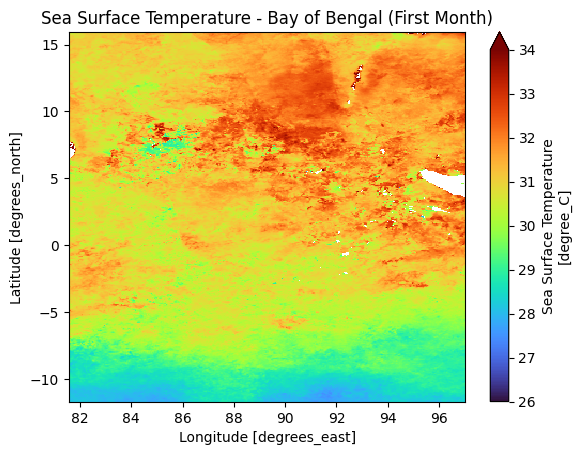

In [ ]:
import matplotlib.pyplot as plt

sst['sst'].isel(time=0).plot(cmap='turbo', vmin=26, vmax=34)
plt.title("Sea Surface Temperature - Bay of Bengal (First Month)")
plt.show()


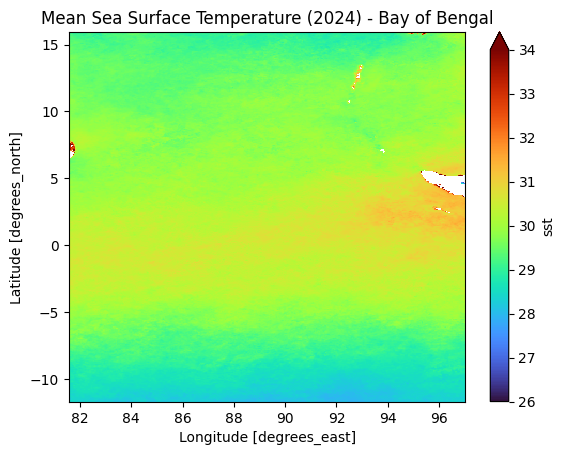

In [ ]:
sst_mean = sst['sst'].mean(dim='time')
sst_mean.plot(cmap='turbo', vmin=26, vmax=34)
plt.title("Mean Sea Surface Temperature (2024) - Bay of Bengal")
plt.show()

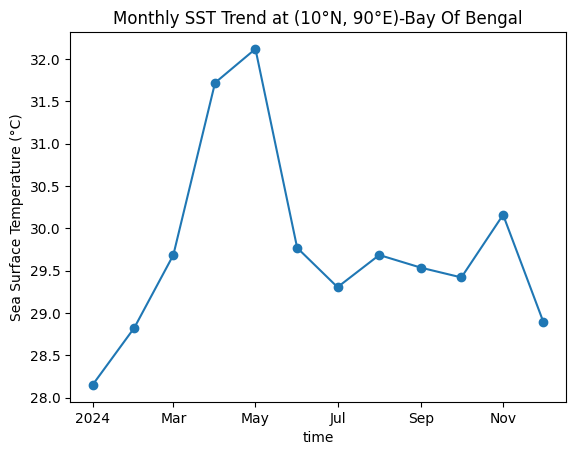

In [ ]:
# Select a point near 10°N, 90°E from the MODIS SST data
# Find the nearest point in the spatial dimensions
sst_point = sst.sel(lat=10, lon=90, method='nearest')['sst']

# Assuming sst_point is an xarray DataArray
sst_point_sorted = sst_point.sortby('time')

# Plot the sorted data
sst_point_sorted.plot(marker='o')
plt.title("Monthly SST Trend at (10°N, 90°E)-Bay Of Bengal")
plt.ylabel("Sea Surface Temperature (°C)")
plt.show()

In [ ]:
# Select a point near 10°N, 90°E from the MODIS SST data
# Find the nearest point in the spatial dimensions
sst_point = sst.sel(lat=10, lon=90, method='nearest')['sst']

print("SST time series at selected point:")
print(sst_point)

SST time series at selected point:
<xarray.DataArray 'sst' (time: 1)> Size: 4B
dask.array<getitem, shape=(1,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 8B 2024-05-01
    lat      float32 4B 10.01
    lon      float32 4B 90.0
Attributes:
    long_name:      Sea Surface Temperature
    units:          degree_C
    standard_name:  sea_surface_temperature
    valid_min:      -1000
    valid_max:      10000
    display_scale:  linear
    display_min:    -2.0
    display_max:    45.0


ARGO data for Bay of Bengal

In [ ]:
!pip install erddapy

In [ ]:
from erddapy import ERDDAP

e = ERDDAP(server="https://erddap.ifremer.fr/erddap", protocol="tabledap")
e.dataset_id = "ArgoFloats"
e.response = "html"
print(e.get_search_url(response="csv"))

https://erddap.ifremer.fr/erddap/search/advanced.csv?page=1&itemsPerPage=1000000&protocol=tabledap&cdm_data_type=(ANY)&institution=(ANY)&ioos_category=(ANY)&keywords=(ANY)&long_name=(ANY)&standard_name=(ANY)&variableName=(ANY)&minLon=(ANY)&maxLon=(ANY)&minLat=(ANY)&maxLat=(ANY)&minTime=&maxTime=


In [ ]:
#LINK USED TO VERIFY THE VARIABLE NAMES
#https://erddap.ifremer.fr/erddap/info/ArgoFloats/index.html

In [ ]:
from erddapy import ERDDAP
import pandas as pd

# Connect to ERDDAP (Ifremer server)
e = ERDDAP(
    server="https://erddap.ifremer.fr/erddap",
    protocol="tabledap"
)

# Dataset ID (you can check your CSV for the exact dataset ID)
e.dataset_id = "ArgoFloats"

# Bay of Bengal bounds + 2024 timeline
e.constraints = {
    "time>=": "2024-05-01T00:00:00Z",
    "time<=": "2024-05-31T23:59:59Z" ,
    "latitude>=": 5,
    "latitude<=": 22,
    "longitude>=": 80,
    "longitude<=": 100
}

# Use lowercase variable names
e.variables = [
    "time","platform_number", "cycle_number", "latitude", "longitude",
    "temp_adjusted", "psal_adjusted", "pres_adjusted"
]

# Download and clean data
df = e.to_pandas(index_col="time (UTC)", parse_dates=True)
#df = df.dropna(subset=["temp_adjusted"])

print(f"\nTotal profiles retrieved: {len(df)}")
df.head()


Total profiles retrieved: 15771


,platform_number,cycle_number,latitude (degrees_north),longitude (degrees_east),temp_adjusted (degree_Celsius),psal_adjusted (PSU),pres_adjusted (decibar)
time (UTC),,,,,,,
2024-05-02 06:26:40+00:00,2902394,315,9.463,87.01263,NaN,NaN,1.20
2024-05-02 06:26:40+00:00,2902394,315,9.463,87.01263,NaN,NaN,2.08
2024-05-02 06:26:40+00:00,2902394,315,9.463,87.01263,NaN,NaN,3.08
2024-05-02 06:26:40+00:00,2902394,315,9.463,87.01263,NaN,NaN,4.08
2024-05-02 06:26:40+00:00,2902394,315,9.463,87.01263,NaN,NaN,5.04


In [ ]:
# Clean and rename columns
df.columns = [c.lower().split(' ')[0] for c in df.columns]
df.rename(columns={
    'platform_number': 'wmo',
    'cycle_number': 'cycle',
    'latitude': 'lat',
    'longitude': 'lon',
    'temp_adjusted': 'temp',
    'psal_adjusted': 'sal',
    'pres_adjusted': 'pres'
}, inplace=True)

df.head()

,wmo,cycle,lat,lon,temp,sal,pres
time (UTC),,,,,,,
2024-05-02 06:26:40+00:00,2902394,315,9.463,87.01263,NaN,NaN,1.20
2024-05-02 06:26:40+00:00,2902394,315,9.463,87.01263,NaN,NaN,2.08
2024-05-02 06:26:40+00:00,2902394,315,9.463,87.01263,NaN,NaN,3.08
2024-05-02 06:26:40+00:00,2902394,315,9.463,87.01263,NaN,NaN,4.08
2024-05-02 06:26:40+00:00,2902394,315,9.463,87.01263,NaN,NaN,5.04


In [ ]:
print(df.columns.tolist())

['wmo', 'cycle', 'lat', 'lon', 'temp', 'sal', 'pres']


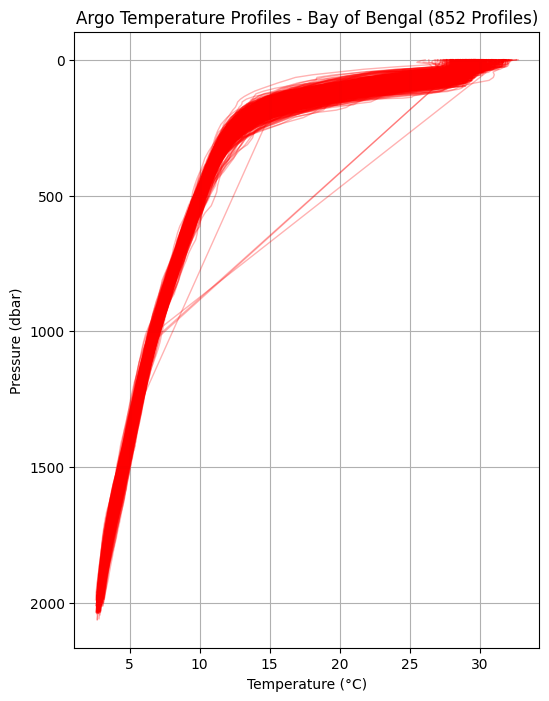

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 8))

# Combine the WMO ID and Cycle number to create a truly unique profile ID
# This accounts for multiple floats (WMOs) operating in the region
df['profile_id'] = df['wmo'].astype(str) + '_' + df['cycle'].astype(str)

# Iterate over each unique profile ID
for profile_id in df['profile_id'].unique():
    # Select all data points belonging to the current profile
    profile_data = df[df['profile_id'] == profile_id]

    # Plot only the points for this single profile.
    # Use transparency to see the density of the profiles
    plt.plot(profile_data['temp'], profile_data['pres'],
             color='red',
             alpha=0.3, # Adjust alpha for better visualization
             linewidth=1)

plt.gca().invert_yaxis()  # Pressure increases with depth
plt.xlabel("Temperature (°C)")
plt.ylabel("Pressure (dbar)")
plt.title(f"Argo Temperature Profiles - Bay of Bengal ({len(df['profile_id'].unique())} Profiles)")
plt.grid(True)
plt.show()

/tmp/ipython-input-850467520.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['week'] = df.index.to_period('W')
/tmp/ipython-input-850467520.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_grid = df.groupby(['week', 'depth_bin'])['temp'].mean().unstack(level='depth_bin')


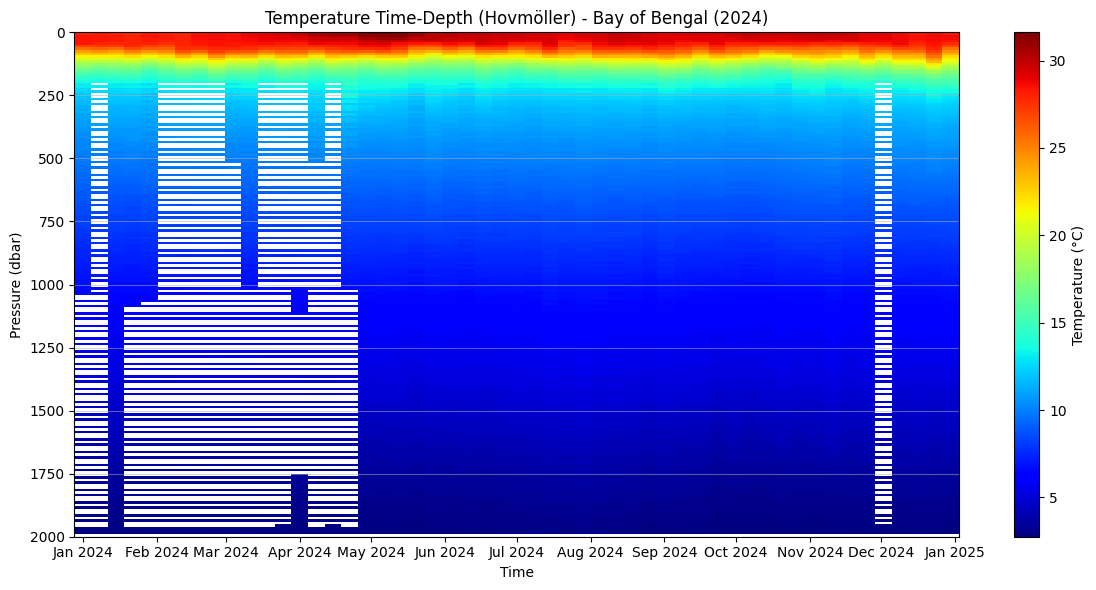

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Time Bin: Group by the **Week** of the year
# We use .to_period('W') to get the week number
df['week'] = df.index.to_period('W')

# Depth Bin: Define a constant depth interval (e.g., 10 dbar)
depth_bins = np.arange(0, 2000, 10) # 0 to 2000 dbar in 10 dbar steps
# Using right=False to make bins like [0, 10), [10, 20), etc.
df['depth_bin'] = pd.cut(df['pres'], bins=depth_bins, labels=depth_bins[:-1] + 5, right=False) # Label with the bin mid-point

# Aggregate: Calculate the mean temperature for each (week, depth_bin) combination
# Use observed=False to ensure all weekly depth bins are included, even if no data
# Note: Older pandas versions might not support 'observed=False'
try:
    temp_grid = df.groupby(['week', 'depth_bin'])['temp'].mean().unstack(level='depth_bin')
except TypeError:
    # Fallback for older pandas versions without 'observed'
    temp_grid = df.groupby(['week', 'depth_bin'])['temp'].mean().unstack(level='depth_bin')


# Prepare the data for plotting
# X-axis: Time (Week numbers)
# Convert PeriodIndex to DateTimeIndex for plotting
X = temp_grid.index.to_timestamp()
# Y-axis: Depth (The bin mid-points)
Y = temp_grid.columns.values
# Z-axis: Temperature values
Z = temp_grid.values.T # Transpose to get (Depth x Time) for plotting

# ----------------------------------------------------------------------
# 3. HOVMÖLLER DIAGRAM PLOTTING
# ----------------------------------------------------------------------

plt.figure(figsize=(12, 6))

# Plot the heatmap (Hovmöller)
# Use 'jet' or 'viridis' for temperature
h = plt.pcolormesh(X, Y, Z, shading='auto', cmap='jet')
cbar = plt.colorbar(h, label='Temperature (°C)')

# Configure axes
plt.gca().invert_yaxis() # Pressure (depth) increases downward
plt.ylim(2000, 0) # Set Y-axis limits (optional, but good practice)

# Format the X-axis for better date readability
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xlabel("Time")
plt.ylabel("Pressure (dbar)")
plt.title(f"Temperature Time-Depth (Hovmöller) - Bay of Bengal (2024)")
plt.grid(True, axis='y', alpha=0.5)

plt.tight_layout()
plt.show()

/tmp/ipython-input-3567066572.py:20: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_level['time_bin'] = df_level.index.to_period('M').to_timestamp()
/tmp/ipython-input-3567066572.py:27: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  temp_grid_df = df_level.pivot_table(


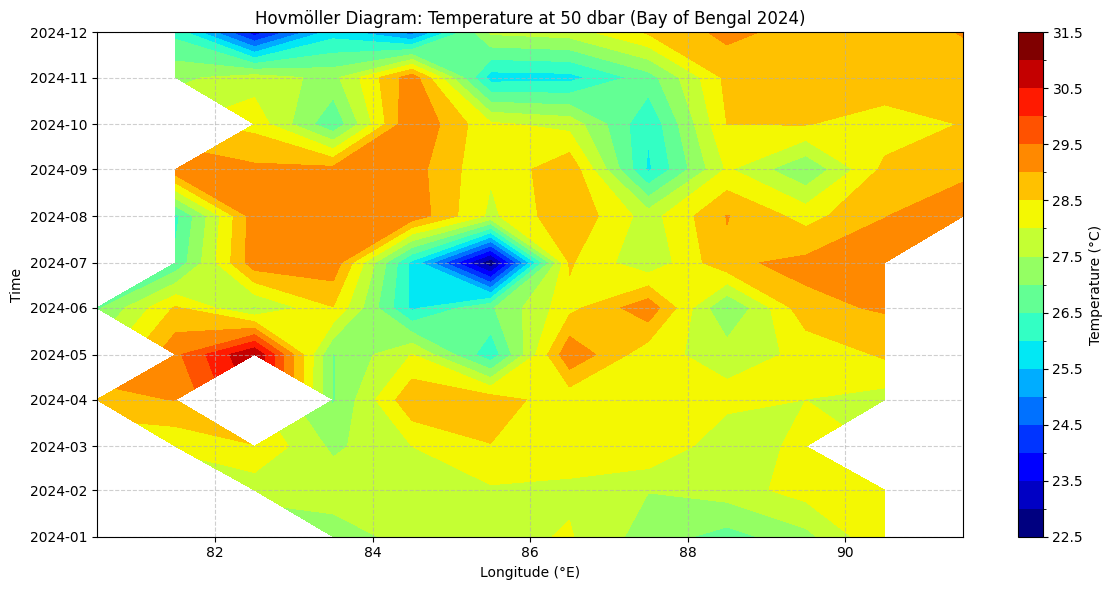

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- Assuming 'df' is the DataFrame loaded from ERDDAP with columns 'lon', 'pres', 'temp' ---

# 1. Select the Depth Level of Interest (e.g., Temperature at 50 dbar)
TARGET_PRESSURE = 50
PRESSURE_TOLERANCE = 10 # Only consider pressures between 40 dbar and 60 dbar

# Filter the DataFrame to include only measurements near the target pressure
df_level = df[
    (df['pres'] >= TARGET_PRESSURE - PRESSURE_TOLERANCE) &
    (df['pres'] <= TARGET_PRESSURE + PRESSURE_TOLERANCE)
].copy()

# Add Time and Longitude bins
# Bin Time by Month
df_level['time_bin'] = df_level.index.to_period('M').to_timestamp()
# Bin Longitude into 1-degree segments (adjust as needed)
lon_bins = np.arange(80, 100 + 1, 1) # Range 80E to 100E
df_level['lon_bin'] = pd.cut(df_level['lon'], bins=lon_bins, labels=lon_bins[:-1] + 0.5)

# 2. Pivot the Data into a Time x Longitude Grid
# Calculate the mean temperature in each (Month, Longitude Bin)
temp_grid_df = df_level.pivot_table(
    index='time_bin',
    columns='lon_bin',
    values='temp',
    aggfunc='mean'
)

# 3. Convert the Pandas DataFrame to an xarray DataArray
# The conversion naturally assigns the index ('time_bin') and columns ('lon_bin') as coordinates
temp_da = xr.DataArray(
    temp_grid_df.values,
    coords=[temp_grid_df.index, temp_grid_df.columns.astype(float)],
    dims=['time', 'longitude'],
    name='temperature'
)

# 4. Create and Plot the Hovmöller Diagram using xarray's method
plt.figure(figsize=(12, 6))

# Use the .plot.contourf method provided by xarray
temp_da.plot.contourf(
    x='longitude',
    y='time',
    levels=20,
    cmap='jet', # Good choice for temperature
    cbar_kwargs={'label': 'Temperature (°C)'}
)

plt.title(f"Hovmöller Diagram: Temperature at {TARGET_PRESSURE} dbar (Bay of Bengal 2024)")
plt.xlabel("Longitude (°E)")
plt.ylabel("Time")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

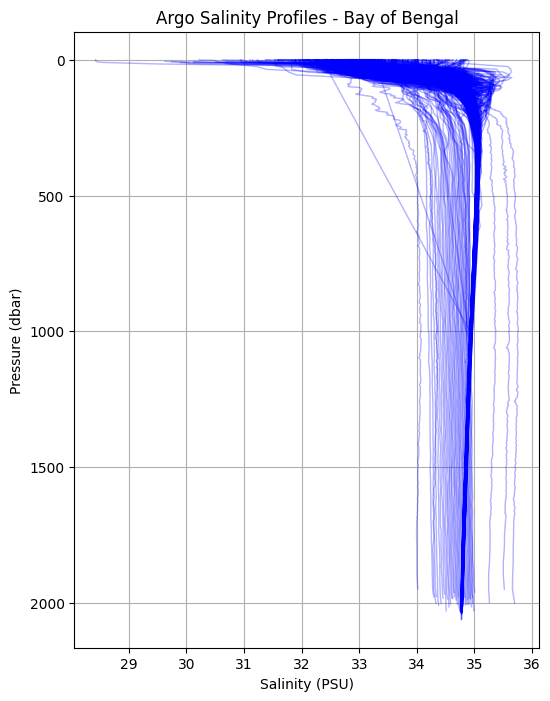

In [ ]:
import matplotlib.pyplot as plt

# --- Ensure 'profile_id' column exists from previous steps ---
# df['profile_id'] = df['wmo'].astype(str) + '_' + df['cycle'].astype(str)

plt.figure(figsize=(6, 8))

# Iterate over each unique profile ID
for profile_id in df['profile_id'].unique():
    # Select all data points belonging to the current profile
    profile_data = df[df['profile_id'] == profile_id]

    # Plot only the points for this single profile.
    # Use transparency (alpha) to visualize the overlap and density.
    plt.plot(profile_data['sal'], profile_data['pres'],
             color='blue',
             alpha=0.3, # Use a lower alpha for many profiles
             linewidth=1)

plt.gca().invert_yaxis()  # pressure increases with depth
plt.xlabel("Salinity (PSU)")
plt.ylabel("Pressure (dbar)")
plt.title("Argo Salinity Profiles - Bay of Bengal")
plt.grid(True)
plt.show()

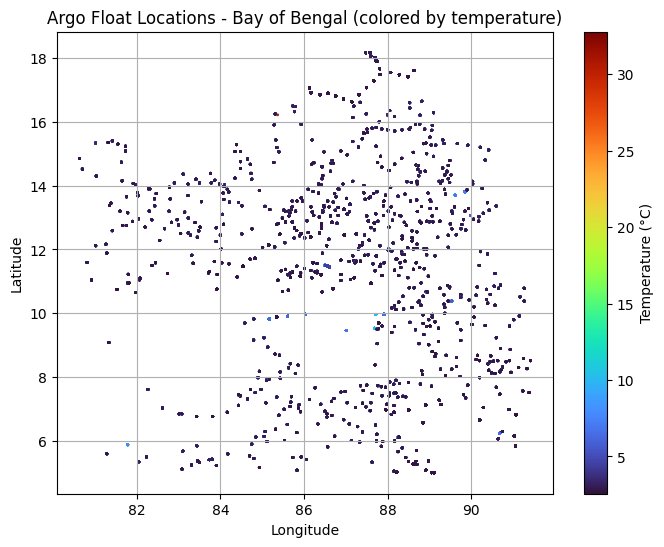

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df['lon'], df['lat'], c=df['temp'], cmap='turbo', s=1)
plt.colorbar(label="Temperature (°C)")
plt.title("Argo Float Locations - Bay of Bengal (colored by temperature)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

Data Integration (ARGO+MODIS)

In [ ]:
import numpy as np

# 1. Get the hour and minute fraction from the UTC timestamp (index)
# 'index' here is your pandas DatetimeIndex (time in UTC)
utc_hour_fraction = df.index.hour + (df.index.minute / 60)

# 2. Calculate the time offset due to longitude (1 hour per 15 degrees)
# Time is positive East of the Prime Meridian.
time_shift = df['lon'] / 15

# 3. Calculate Local Solar Time (LST)
df['lst'] = utc_hour_fraction + time_shift

# 4. Normalize LST to stay within 0 to 24 hours (e.g., 25.0 becomes 1.0)
df['lst'] = df['lst'] % 24

print("Local Time of Day (LST) calculated successfully for all Argo points.")
df[['lon', 'lst']].head()

Local Time of Day (LST) calculated successfully for all Argo points.


,lon,lst
time (UTC),,
2024-05-02 06:26:40+00:00,87.01263,12.234175
2024-05-02 06:26:40+00:00,87.01263,12.234175
2024-05-02 06:26:40+00:00,87.01263,12.234175
2024-05-02 06:26:40+00:00,87.01263,12.234175
2024-05-02 06:26:40+00:00,87.01263,12.234175


In [ ]:
!pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 94.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 55.9 MB/s eta 0:00:00


In [ ]:
import zipfile
import os

zip_path = "/content/era5_wind_2024_bob.zip"
extract_dir = "era5_wind_data"

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Files extracted to:", extract_dir)
print("Contents:", os.listdir(extract_dir))


Files extracted to: era5_wind_data
Contents: ['data_stream-oper_stepType-instant.nc']


In [ ]:
import xarray as xr
import os

file_path = os.path.join("era5_wind_data", "data_stream-oper_stepType-instant.nc")
ds = xr.open_dataset(file_path)

print(ds)


<xarray.Dataset> Size: 538kB
Dimensions:     (valid_time: 12, latitude: 69, longitude: 81)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 96B 2024-01-01 ... 2024-12-01
  * latitude    (latitude) float64 552B 22.0 21.75 21.5 21.25 ... 5.5 5.25 5.0
  * longitude   (longitude) float64 648B 80.0 80.25 80.5 ... 99.5 99.75 100.0
    number      int64 8B ...
    expver      (valid_time) <U4 192B ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 268kB ...
    v10         (valid_time, latitude, longitude) float32 268kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-10-28T15:32 GRIB to CDM+CF via cfgrib-0.9.1...


In [ ]:
ds["wind_speed"] = np.sqrt(ds["u10"]**2 + ds["v10"]**2)
print(ds["wind_speed"])


<xarray.DataArray 'wind_speed' (valid_time: 12, latitude: 69, longitude: 81)> Size: 268kB
array([[[ 1.0702764 ,  1.4508245 ,  1.6916519 , ...,  0.7996414 ,
          0.92740947,  0.7254088 ],
        [ 1.1192784 ,  1.1809769 ,  1.5715499 , ...,  0.09439705,
          0.64422107,  0.936529  ],
        [ 1.7631948 ,  1.4998778 ,  1.6979924 , ...,  0.7320882 ,
          0.6752013 ,  0.10592313],
        ...,
        [ 6.802864  ,  6.8927903 ,  6.986331  , ...,  4.778001  ,
          4.2955174 ,  3.5884295 ],
        [ 6.999746  ,  6.7459    ,  6.573949  , ...,  4.0824046 ,
          4.0385695 ,  3.7500498 ],
        [ 6.448177  ,  6.2638063 ,  6.2203546 , ...,  3.4434097 ,
          3.8272443 ,  3.8899286 ]],

       [[ 1.4766853 ,  0.9673902 ,  1.394293  , ...,  0.998414  ,
          1.1667626 ,  1.0551944 ],
        [ 1.2873408 ,  1.3504118 ,  1.4064499 , ...,  1.0290868 ,
          1.0144987 ,  1.0954521 ],
        [ 1.6424475 ,  1.5232255 ,  1.3626562 , ...,  0.74444133,
          1.0

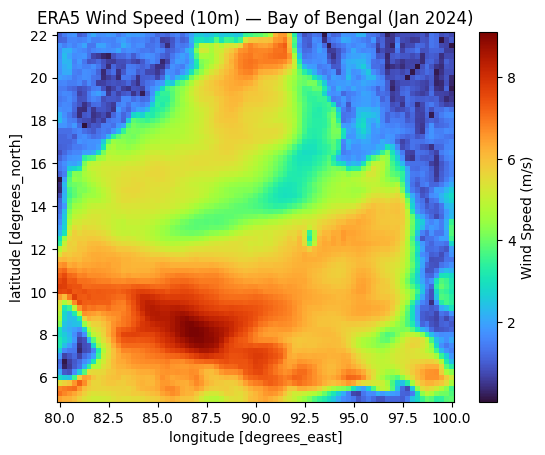

In [ ]:
ds["wind_speed"].isel(valid_time=0).plot(
    cmap="turbo",
    cbar_kwargs={"label": "Wind Speed (m/s)"}
)
plt.title("ERA5 Wind Speed (10m) — Bay of Bengal (Jan 2024)")
plt.show()


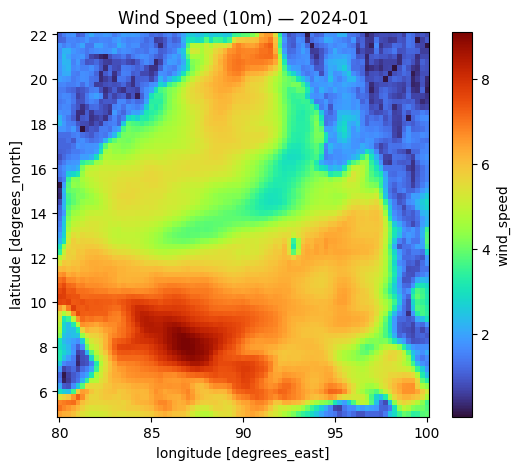

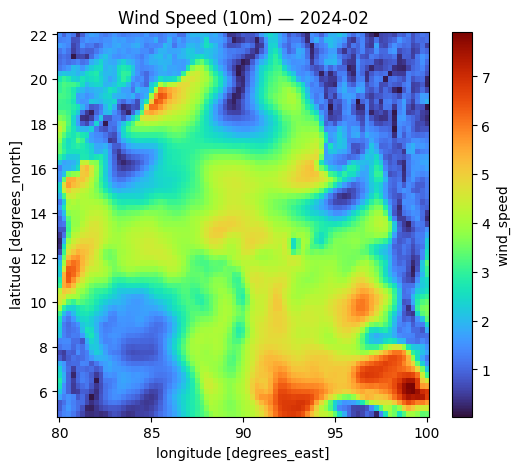

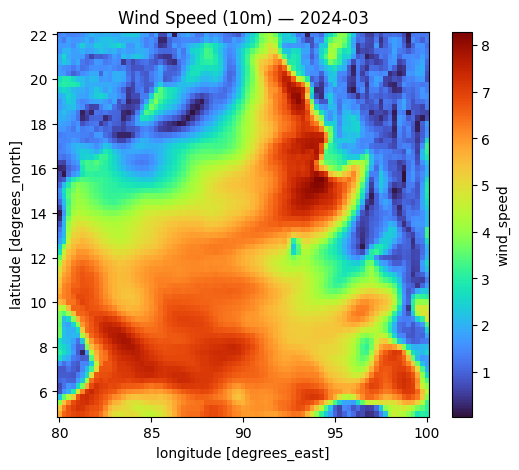

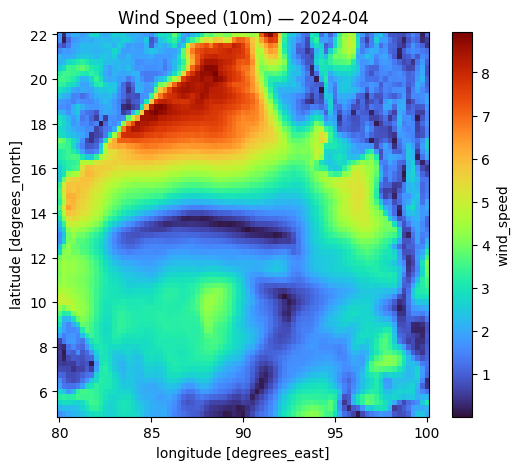

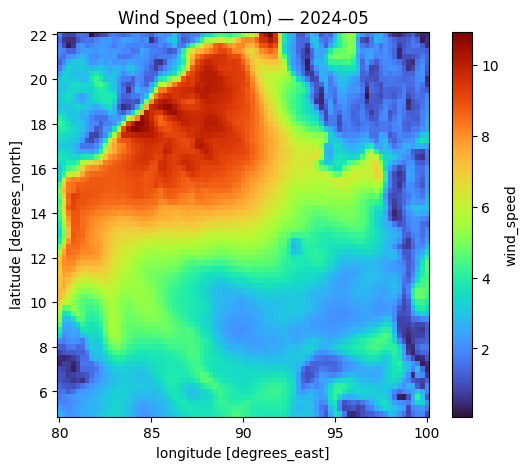

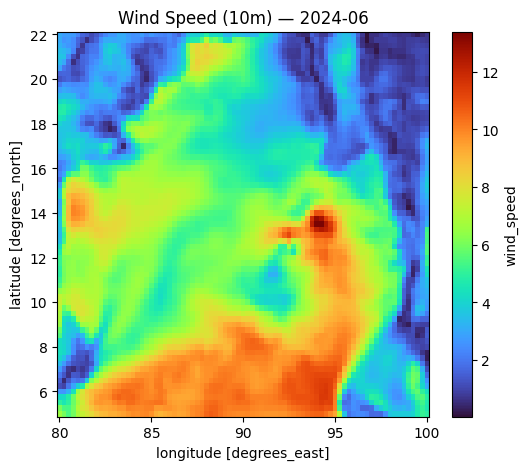

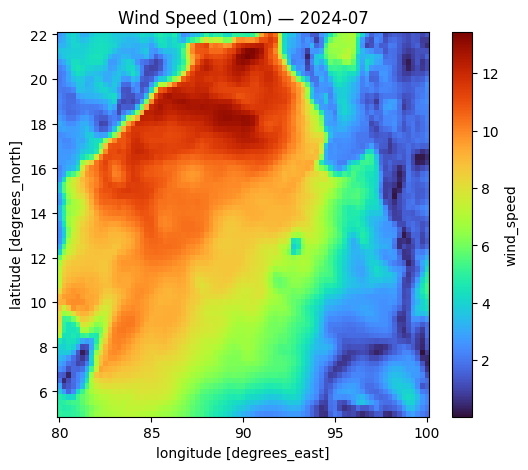

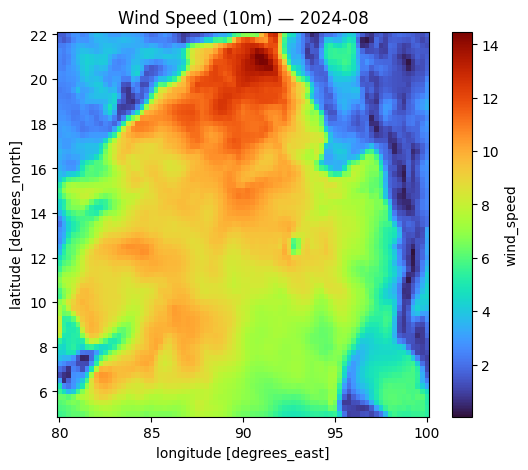

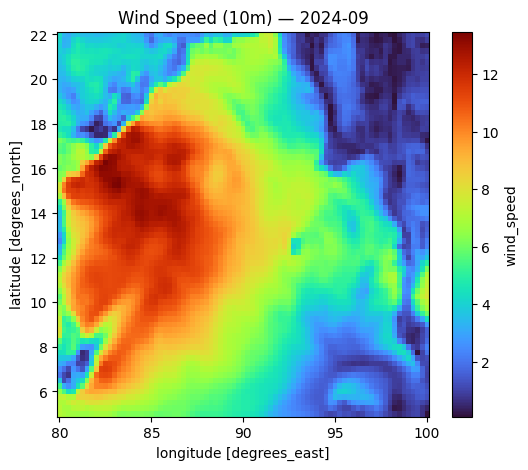

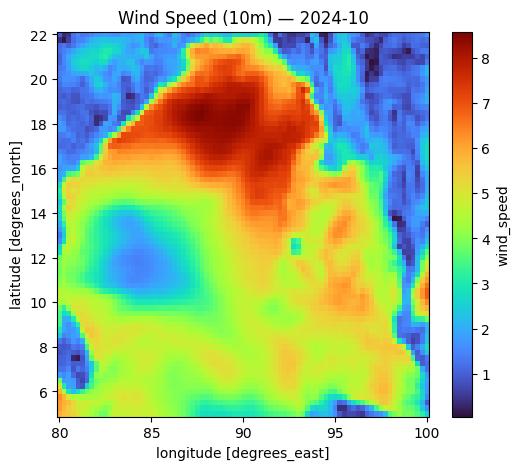

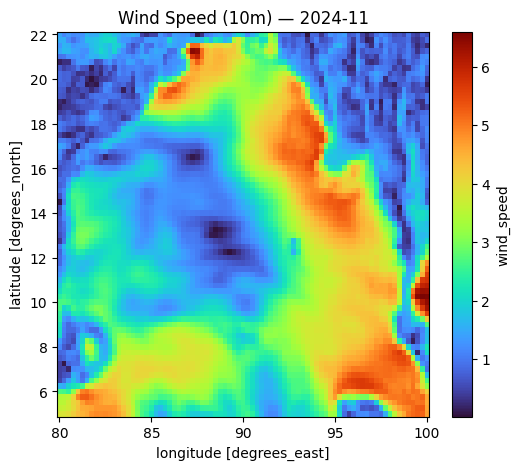

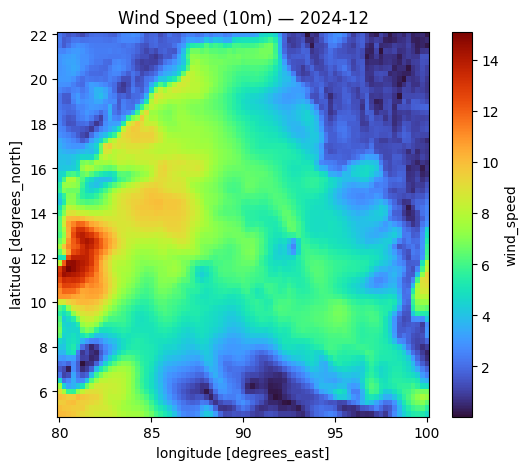

In [ ]:
for i, t in enumerate(ds.valid_time.values):
    plt.figure(figsize=(6,5))
    ds["wind_speed"].isel(valid_time=i).plot(cmap="turbo")
    plt.title(f"Wind Speed (10m) — {str(np.datetime_as_string(t, unit='M'))}")
    plt.show()


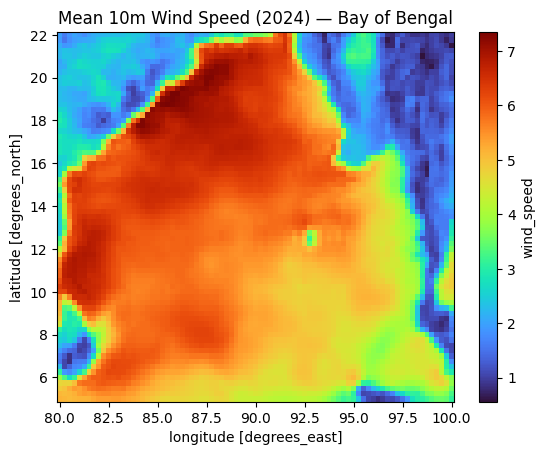

In [ ]:
# Mean over time (2024 average)
mean_wind = ds["wind_speed"].mean(dim="valid_time")

mean_wind.plot(cmap="turbo")
plt.title("Mean 10m Wind Speed (2024) — Bay of Bengal")
plt.show()


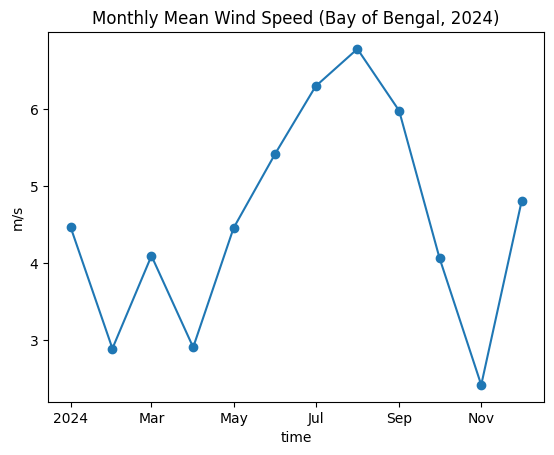

In [ ]:
monthly_mean = ds["wind_speed"].mean(dim=["latitude", "longitude"])
monthly_mean.plot(marker='o')
plt.title("Monthly Mean Wind Speed (Bay of Bengal, 2024)")
plt.ylabel("m/s")
plt.show()


In [ ]:
import numpy as np
import xarray as xr
import pandas as pd
from scipy.interpolate import griddata

# --- ASSUMPTION: df (Argo), sst (MODIS) are loaded and ready ---

# 1. Argo Preprocessing and Surface Filtering
TARGET_DEPTH = 10 # dbar
surface_argo = df[df['pres'] <= TARGET_DEPTH].copy()

# 2. Calculate Local Solar Time (LST) - Contextual Feature
utc_hour_fraction = surface_argo.index.hour + (surface_argo.index.minute / 60)
time_shift = surface_argo['lon'] / 15
surface_argo['lst'] = (utc_hour_fraction + time_shift) % 24

# 3. Prepare Argo coordinates for Interpolation
argo_lats = surface_argo['lat'].values
argo_lons = surface_argo['lon'].values
argo_times = surface_argo.index # DatetimeIndex of the Argo measurements


# --- 4. FUSION: Interpolate MODIS SST onto Argo points (CORE STEP) ---
print("Starting CORE Argo-MODIS Spatio-Temporal Interpolation...")

try:
    # 4a. Interpolate MODIS SST onto Argo points
    interpolated_sst_da = sst['sst'].interp(
        time=argo_times,
        lat=argo_lats,
        lon=argo_lons,
        method="linear",
        kwargs={"fill_value": np.nan}
    )

    # CRITICAL: Convert the interpolated DataArray to a pandas Series, aligning the index
    interpolated_sst_series = interpolated_sst_da.to_series()
    interpolated_sst_series.index = surface_argo.index
    #surface_argo['modis_sst'] = interpolated_sst_series

    print(" MODIS SST interpolation complete.")

except Exception as e:
    print(f"FAILED during interpolation: {e}")
    # End the process if the core fusion fails

# --- 5. Final Feature Engineering and Cleaning ---

# Calculate the unique feature: Delta T (MODIS Skin - Argo Bulk)
#surface_argo['delta_t'] = surface_argo['modis_sst'] - surface_argo['temp']

# Drop records where essential interpolated data is missing
#surface_argo.dropna(subset=['modis_sst', 'delta_t'], inplace=True)


print("\n--- CORE ARGO + MODIS FUSION COMPLETE ---")
print(f"Total fully integrated and cleaned records: {len(surface_argo)}")
print("\nKey features generated (ready for Delta T analysis):")
surface_argo[['temp', 'lst']]

Starting CORE Argo-MODIS Spatio-Temporal Interpolation...
FAILED during interpolation: When interpolating over a datetime-like coordinate, the coordinates to interpolate to must be either datetime strings or datetimes. Instead got
<xarray.Variable (time: 719)> Size: 6kB
array([Timestamp('2024-05-02 06:26:40+0000', tz='UTC'),
       Timestamp('2024-05-02 06:26:40+0000', tz='UTC'),
       Timestamp('2024-05-02 06:26:40+0000', tz='UTC'),
       Timestamp('2024-05-02 06:26:40+0000', tz='UTC'),
       Timestamp('2024-05-02 06:26:40+0000', tz='UTC'),
       Timestamp('2024-05-02 06:26:40+0000', tz='UTC'),
       Timestamp('2024-05-02 06:26:40+0000', tz='UTC'),
       Timestamp('2024-05-02 06:26:40+0000', tz='UTC'),
       Timestamp('2024-05-02 06:26:40+0000', tz='UTC'),
       Timestamp('2024-05-04 07:29:13+0000', tz='UTC'),
       Timestamp('2024-05-04 07:29:13+0000', tz='UTC'),
       Timestamp('2024-05-04 07:29:13+0000', tz='UTC'),
       Timestamp('2024-05-04 07:29:13+0000', tz='UTC'),
 

,temp,lst
time (UTC),,
2024-05-02 06:26:40+00:00,NaN,12.234175
2024-05-02 06:26:40+00:00,NaN,12.234175
2024-05-02 06:26:40+00:00,NaN,12.234175
2024-05-02 06:26:40+00:00,NaN,12.234175
2024-05-02 06:26:40+00:00,NaN,12.234175
...,...,...
2024-05-15 02:29:26+00:00,30.4420,8.392144
2024-05-15 02:29:26+00:00,30.3564,8.392144
2024-05-24 23:43:46+00:00,31.0470,5.615887


Pre-Checks

In [ ]:
print("Argo latitude range:", df["lat"].min(), "to", df["lat"].max())
print("Argo longitude range:", df["lon"].min(), "to", df["lon"].max())
print("MODIS latitude range:", sst["lat"].min().values, "to", sst["lat"].max().values)
print("MODIS longitude range:", sst["lon"].min().values, "to", sst["lon"].max().values)


Argo latitude range: 6.0 to 15.771
Argo longitude range: 81.528 to 90.597
MODIS latitude range: -11.689180374145508 to 15.91917896270752
MODIS longitude range: 81.58084869384766 to 97.00914764404297


In [ ]:
print("Argo time range:", df.index.min(), "to", df.index.max())
print("MODIS time range:", sst["time"].min().values, "to", sst["time"].max().values)


Argo time range: 2024-05-02 06:26:40+00:00 to 2024-05-07 14:00:25+00:00
MODIS time range: 2024-05-01T00:00:00.000000000 to 2024-05-01T00:00:00.000000000


In [ ]:
print("Valid MODIS SST count:", np.isfinite(sst['sst']).sum().values)

Valid MODIS SST count: 244707


Data FUSION

In [ ]:
import numpy as np
import xarray as xr
import pandas as pd
from scipy.interpolate import griddata

# --- ASSUMPTION: df (Argo), sst (MODIS) are loaded and ready ---

# 1. Argo Preprocessing and Surface Filtering
TARGET_DEPTH = 10 # dbar
surface_argo = df[df['pres'] <= TARGET_DEPTH].copy()

# 2. Calculate Local Solar Time (LST) - Contextual Feature
utc_hour_fraction = surface_argo.index.hour + (surface_argo.index.minute / 60)
time_shift = surface_argo['lon'] / 15
surface_argo['lst'] = (utc_hour_fraction + time_shift) % 24

# 3. Prepare Argo coordinates for Interpolation
argo_lats = surface_argo['lat'].values
argo_lons = surface_argo['lon'].values
argo_times = pd.to_datetime(argo_times).tz_localize(None).to_numpy()

# --- 4. FUSION: Interpolate MODIS SST onto Argo points (CORE STEP) ---

try:
    # 4a. Interpolate MODIS SST onto Argo points
    interpolated_sst_da = sst['sst'].isel(time=0).interp(
    #time=xr.DataArray(argo_times, dims="points"),
    lat=xr.DataArray(argo_lats, dims="points"),
    lon=xr.DataArray(argo_lons, dims="points"),
    method="nearest"  # safer than linear for sparse data
    )

    # CRITICAL: Convert the interpolated DataArray to a pandas Series, aligning the index
    interpolated_sst_series = interpolated_sst_da.to_series()
    interpolated_sst_series.index = surface_argo.index
    #surface_argo['modis_sst'] = interpolated_sst_series


    interpolated_sst_series = pd.Series(interpolated_sst_da.values, index=surface_argo.index)
    surface_argo["modis_sst"] = interpolated_sst_series

except Exception as e:
    print(f"FAILED during interpolation: {e}")
    # End the process if the core fusion fails

# --- 5. Final Feature Engineering and Cleaning ---

# Calculate the unique feature: Delta T (MODIS Skin - Argo Bulk)
surface_argo['delta_t'] = surface_argo['modis_sst'] - surface_argo['temp']

# Drop records where essential interpolated data is missing
surface_argo.dropna(subset=['modis_sst', 'temp'], inplace=True)

print(f"Total fully integrated and cleaned records: {len(surface_argo)}")
print("\nKey features generated: temp, modis_sst, delta_t, lst")
surface_argo[["temp", "modis_sst", "delta_t", "lst"]].head()

Total fully integrated and cleaned records: 682

Key features generated: temp, modis_sst, delta_t, lst


,temp,modis_sst,delta_t,lst
time (UTC),,,,
2024-05-04 07:29:13+00:00,32.163,31.719999,-0.443001,13.249754
2024-05-04 07:29:13+00:00,32.125,31.719999,-0.405001,13.249754
2024-05-04 07:29:13+00:00,31.981,31.719999,-0.261001,13.249754
2024-05-04 07:29:13+00:00,31.884,31.719999,-0.164001,13.249754
2024-05-04 07:29:13+00:00,31.872,31.719999,-0.152001,13.249754


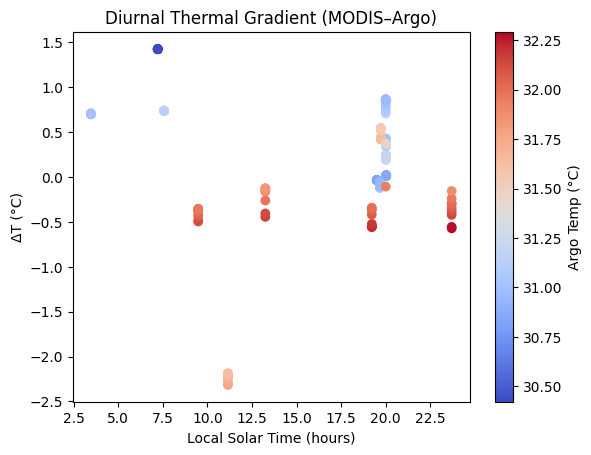

In [ ]:
plt.scatter(surface_argo["lst"], surface_argo["delta_t"], c=surface_argo["temp"], cmap="coolwarm")
plt.xlabel("Local Solar Time (hours)")
plt.ylabel("ΔT (°C)")
plt.title("Diurnal Thermal Gradient (MODIS–Argo)")
plt.colorbar(label="Argo Temp (°C)")
plt.show()


Integrating ERA5 wind data

In [ ]:
ds['u10_speed'] = np.sqrt(ds['u10']**2 + ds['v10']**2)

In [ ]:
ds = ds.rename({'valid_time': 'time'})

In [ ]:
ds['latitude'] = ds['latitude']
ds['longitude'] = ds['longitude']

In [ ]:
# Prepare coordinate arrays
argo_times = pd.to_datetime(surface_argo.index).tz_localize(None).to_numpy()
argo_lats = surface_argo['lat'].values
argo_lons = surface_argo['lon'].values

# Interpolation
interpolated_wind_da = ds['wind_speed'].interp(
    time=xr.DataArray(argo_times, dims="points"),
    latitude=xr.DataArray(argo_lats, dims="points"),
    longitude=xr.DataArray(argo_lons, dims="points"),
    method="nearest"
)

# Add to DataFrame
surface_argo["wind_speed"] = interpolated_wind_da.values

In [ ]:
surface_argo[['temp', 'modis_sst', 'delta_t', 'wind_speed']].head()

,temp,modis_sst,delta_t,wind_speed
time (UTC),,,,
2024-05-04 07:29:13+00:00,32.163,31.719999,-0.443001,4.703088
2024-05-04 07:29:13+00:00,32.125,31.719999,-0.405001,4.703088
2024-05-04 07:29:13+00:00,31.981,31.719999,-0.261001,4.703088
2024-05-04 07:29:13+00:00,31.884,31.719999,-0.164001,4.703088
2024-05-04 07:29:13+00:00,31.872,31.719999,-0.152001,4.703088


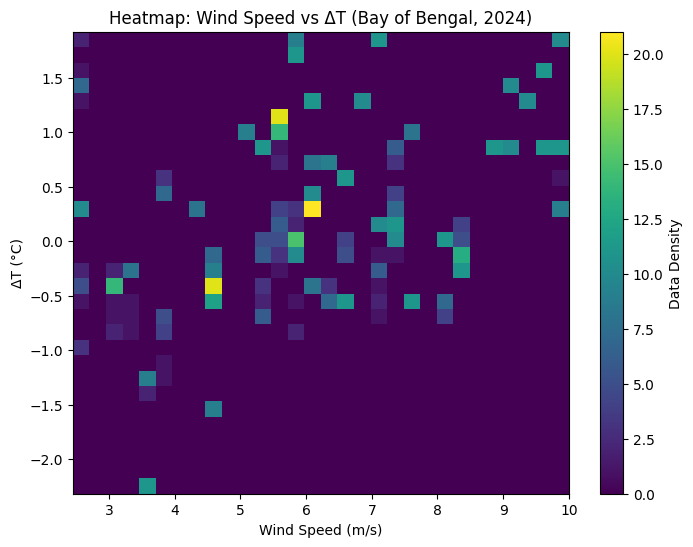

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.hist2d(surface_argo["wind_speed"], surface_argo["delta_t"],
           bins=(30,30), cmap='viridis')

plt.colorbar(label='Data Density')
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("ΔT (°C)")
plt.title("Heatmap: Wind Speed vs ΔT (Bay of Bengal, 2024)")
plt.show()


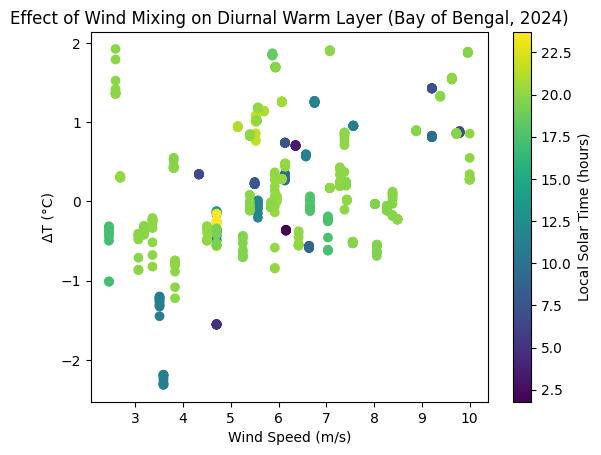

In [ ]:
plt.scatter(surface_argo["wind_speed"], surface_argo["delta_t"], c=surface_argo["lst"], cmap="viridis")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("ΔT (°C)")
plt.title("Effect of Wind Mixing on Diurnal Warm Layer (Bay of Bengal, 2024)")
plt.colorbar(label="Local Solar Time (hours)")
plt.show()


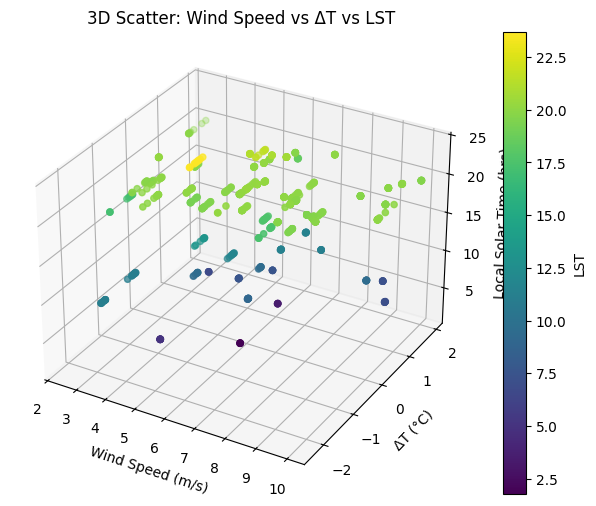

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(surface_argo["wind_speed"],
                surface_argo["delta_t"],
                surface_argo["lst"],
                c=surface_argo["lst"], cmap="viridis")

ax.set_xlabel("Wind Speed (m/s)")
ax.set_ylabel("ΔT (°C)")
ax.set_zlabel("Local Solar Time (hrs)")
plt.title("3D Scatter: Wind Speed vs ΔT vs LST")
plt.colorbar(sc, label='LST')
plt.show()


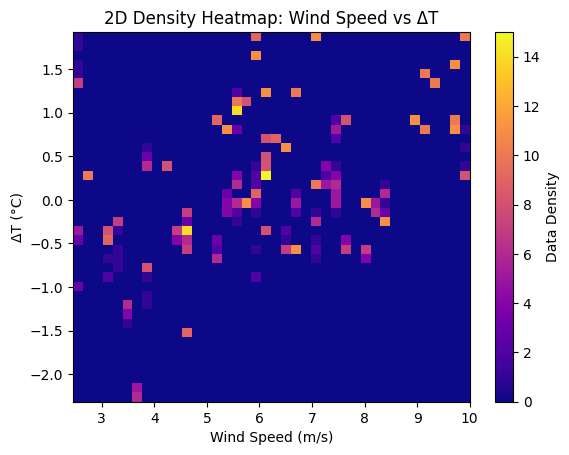

In [ ]:
plt.hist2d(surface_argo["wind_speed"], surface_argo["delta_t"],
           bins=(40,40), cmap='plasma')
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("ΔT (°C)")
plt.title("2D Density Heatmap: Wind Speed vs ΔT")
plt.colorbar(label="Data Density")
plt.show()


In [ ]:
print(surface_argo.columns)


Index(['wmo', 'cycle', 'lat', 'lon', 'temp', 'sal', 'pres', 'lst', 'modis_sst',
       'delta_t', 'wind_speed'],
      dtype='object')


In [ ]:
# Assuming 'ds' is your ERA5 dataset with u10 and v10 components
ds['wind_speed'] = np.sqrt(ds['u10']**2 + ds['v10']**2)

# Convert to DataFrame
wind_df = ds[['wind_speed']].to_dataframe().reset_index()

# Match times to Argo timestamps
surface_argo = pd.merge_asof(
    surface_argo.sort_index().tz_localize(None), # Remove timezone from surface_argo index
    wind_df.sort_values('time'),
    left_index=True, right_on='time',
    direction='nearest', tolerance=pd.Timedelta('1D')
)

surface_argo.rename(columns={'wind_speed_x': 'wind_speed'}, inplace=True, errors='ignore')

In [ ]:
print(surface_argo.columns)


Index(['wmo', 'cycle', 'lat', 'lon', 'temp', 'sal', 'pres', 'lst', 'modis_sst',
       'delta_t', 'wind_speed', 'time', 'latitude', 'longitude',
       'wind_speed_y', 'number', 'expver'],
      dtype='object')


In [ ]:
surface_argo['class'] = np.select(
    [
        (surface_argo['delta_t'] > 0.3) & (surface_argo['wind_speed'] < 4),  # Warm layer, calm winds
        (surface_argo['delta_t'] <= 0.3) & (surface_argo['delta_t'] > -0.3), # Neutral
        (surface_argo['delta_t'] < -0.3) & (surface_argo['wind_speed'] > 6)  # Cooling, strong winds
    ],
    ['DWL', 'Mixed', 'Cooling'],
    default='Uncertain'
)


In [ ]:
surface_argo['class'].value_counts()


,count
class,
Uncertain,404
Mixed,193
Cooling,55
DWL,30


In [ ]:
# Example thresholds — tweak if needed
DWL_DT = 0.3    # ΔT > 0.3°C indicates strong skin warming
CALM_WIND = 3.0 # wind < 3 m/s indicates low mixing
MIXED_WIND = 5.0

import numpy as np

conds = [
    (surface_argo["delta_t"] > DWL_DT) & (surface_argo["wind_speed"] < CALM_WIND),
    (surface_argo["wind_speed"] >= MIXED_WIND),
    (surface_argo["delta_t"] < 0)
]
choices = ["DWL", "Mixed", "Cooling"]
surface_argo["event_flag"] = np.select(conds, choices, default="Unclassified")

surface_argo["event_flag"].value_counts()


,count
event_flag,
Mixed,511
Cooling,132
DWL,20
Unclassified,19


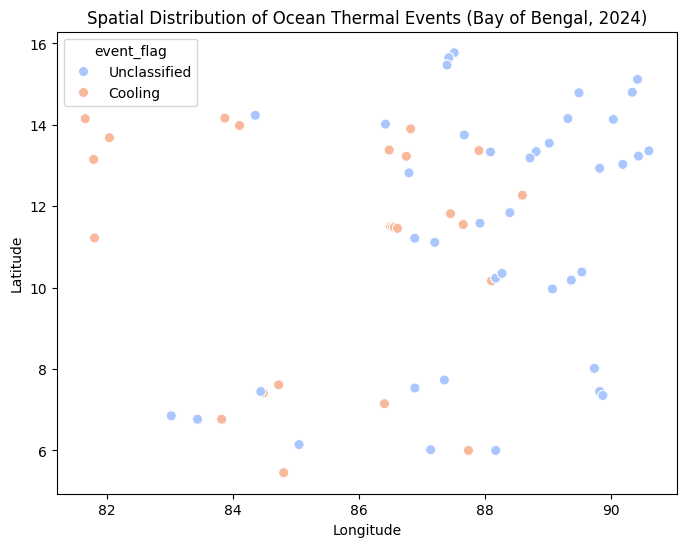

In [ ]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=surface_argo,
    x="lon", y="lat", hue="event_flag", palette="coolwarm", s=50
)
plt.title("Spatial Distribution of Ocean Thermal Events (Bay of Bengal, 2024)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


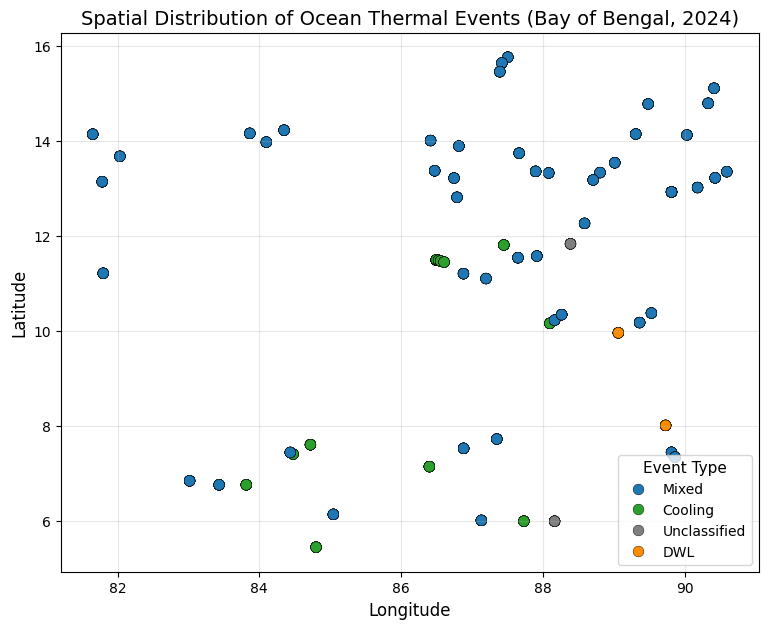

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define custom color palette for 4 classes
custom_palette = {
    'DWL': '#FF8C00',          # warm orange
    'Mixed': '#1f77b4',        # blue
    'Cooling': '#2ca02c',      # green
    'Unclassified': '#7f7f7f'  # grey
}

plt.figure(figsize=(9,7))
sns.scatterplot(
    data=surface_argo,
    x="lon", y="lat",
    hue="event_flag",
    palette=custom_palette,
    s=60,
    edgecolor="black",
    linewidth=0.3
)

plt.title("Spatial Distribution of Ocean Thermal Events (Bay of Bengal, 2024)", fontsize=14)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)

plt.legend(title="Event Type", fontsize=10, title_fontsize=11)
plt.grid(alpha=0.3)

plt.show()


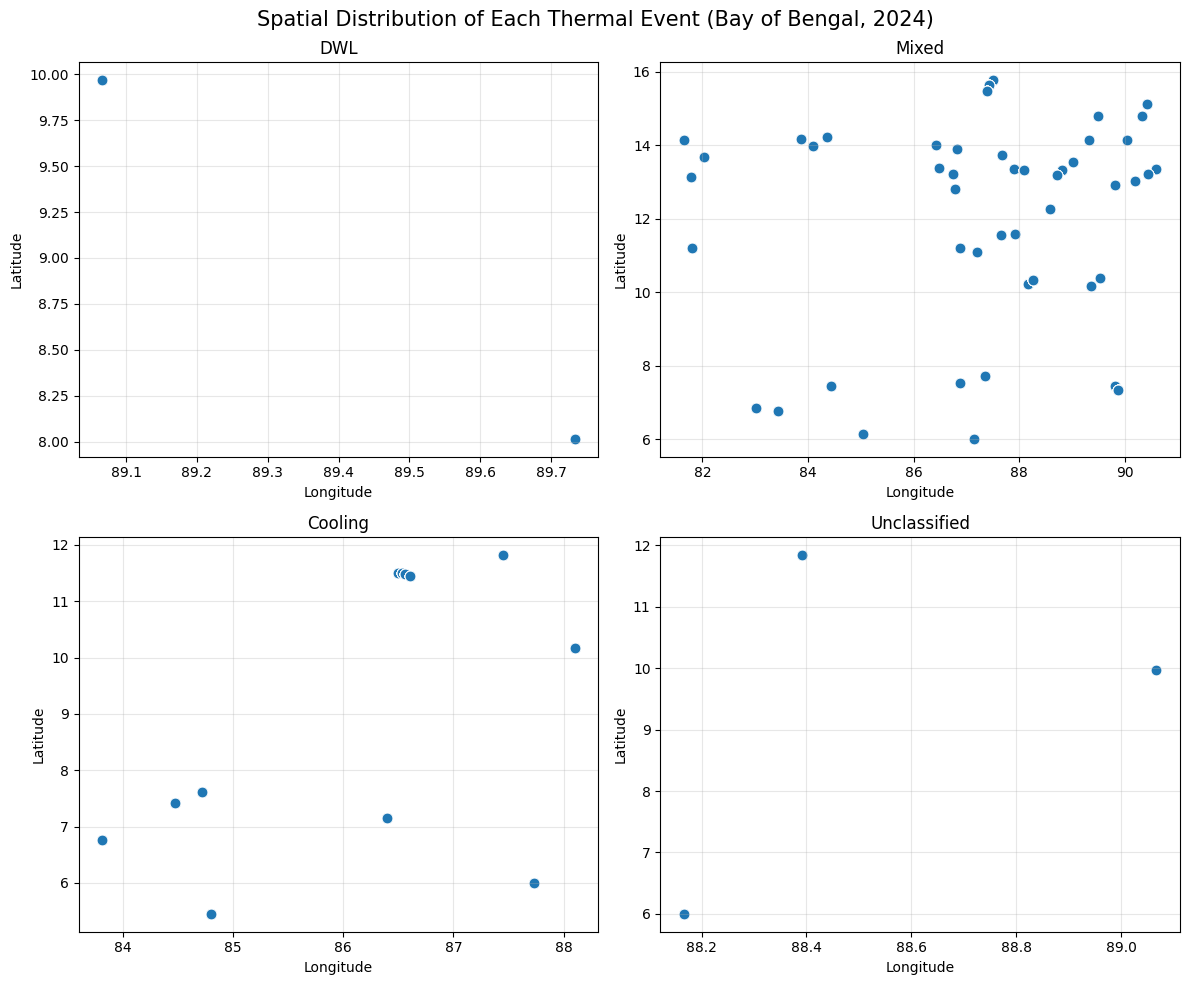

In [ ]:
import seaborn as sns
fig, axes = plt.subplots(2, 2, figsize=(12,10))

event_types = ['DWL','Mixed','Cooling','Unclassified']

for ax, evt in zip(axes.flat, event_types):
    sns.scatterplot(
        data=surface_argo[surface_argo['event_flag']==evt],
        x="lon", y="lat", s=60, ax=ax
    )
    ax.set_title(evt)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(alpha=0.3)

plt.suptitle("Spatial Distribution of Each Thermal Event (Bay of Bengal, 2024)", fontsize=15)
plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


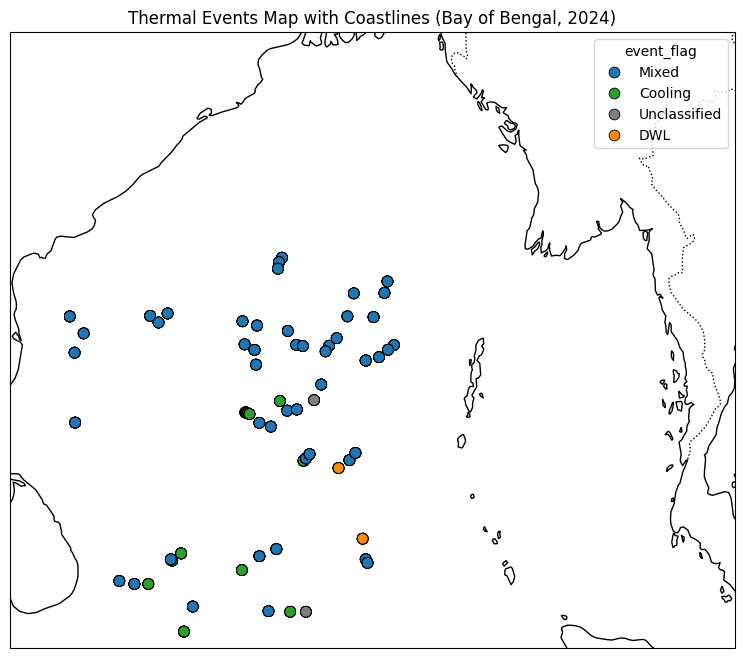

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10,8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_extent([80, 100, 5, 22])

sns.scatterplot(
    data=surface_argo,
    x="lon", y="lat",
    hue="event_flag",
    palette=custom_palette,
    s=60, edgecolor="black", ax=ax
)

plt.title("Thermal Events Map with Coastlines (Bay of Bengal, 2024)")
plt.show()


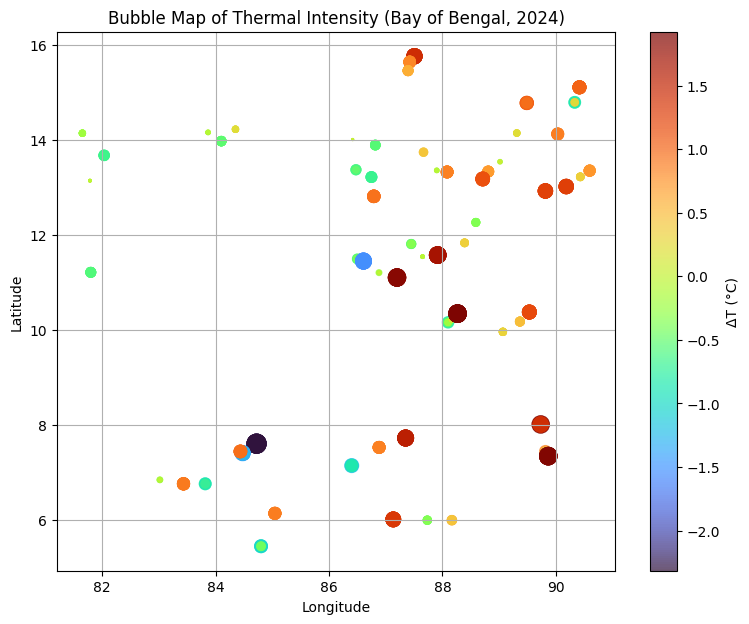

In [ ]:
plt.figure(figsize=(9,7))
plt.scatter(surface_argo["lon"], surface_argo["lat"],
            s=surface_argo["delta_t"].abs()*80,   # bubble size
            c=surface_argo["delta_t"], cmap='turbo',
            alpha=0.7)

plt.colorbar(label="ΔT (°C)")
plt.title("Bubble Map of Thermal Intensity (Bay of Bengal, 2024)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()


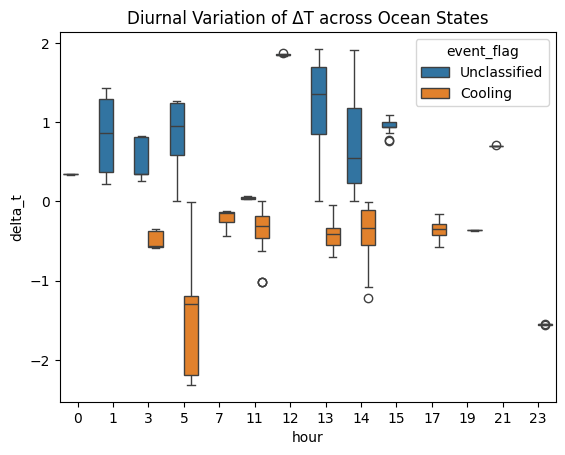

In [ ]:
surface_argo['hour'] = surface_argo.index.hour
sns.boxplot(data=surface_argo, x='hour', y='delta_t', hue='event_flag')
plt.title("Diurnal Variation of ΔT across Ocean States")
plt.show()

Validation of thermal events

Validation Analysis: Wind, ΔT, and Local Solar Time

Correlation between ΔT and Wind Speed: 0.407

Average conditions by event type:
               delta_t  wind_speed       temp
event_flag                                   
Cooling      -0.750470    3.883420  31.835015
DWL           0.947449    2.632421  31.919550
Mixed         0.497232    7.094500  30.981818
Unclassified  0.400842    3.969120  31.549947


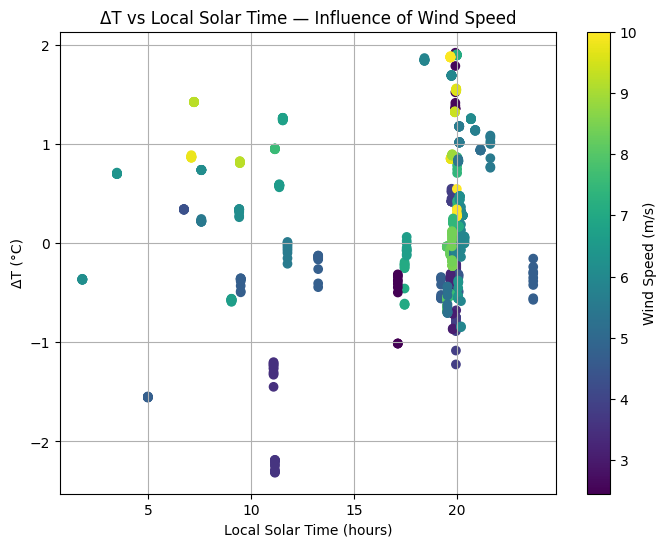

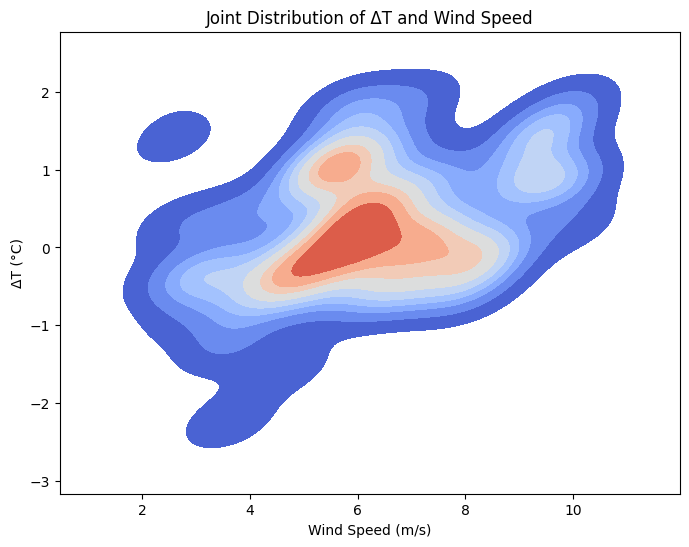

In [ ]:
# --- PHASE 1: VALIDATION ANALYSIS ---
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("Validation Analysis: Wind, ΔT, and Local Solar Time")

# Correlation check
corr = surface_argo[['delta_t', 'wind_speed']].corr().iloc[0,1]
print(f"\nCorrelation between ΔT and Wind Speed: {corr:.3f}")
# Expect negative correlation (wind mixing reduces ΔT)

#  Average conditions per event type
summary = surface_argo.groupby('event_flag')[['delta_t','wind_speed','temp']].mean()
print("\nAverage conditions by event type:")
print(summary)

# ΔT vs Local Solar Time (diurnal pattern)
plt.figure(figsize=(8,6))
# FIX: Use plt.scatter directly to ensure a mappable object is returned for colorbar
sc = plt.scatter(x=surface_argo['lst'], y=surface_argo['delta_t'],
                 c=surface_argo['wind_speed'], cmap='viridis')
plt.title("ΔT vs Local Solar Time — Influence of Wind Speed")
plt.xlabel("Local Solar Time (hours)")
plt.ylabel("ΔT (°C)")
plt.colorbar(sc, label='Wind Speed (m/s)') # Pass the mappable 'sc' to colorbar
plt.grid(True)
plt.show()

# Wind–ΔT joint distribution
plt.figure(figsize=(8,6))
sns.kdeplot(data=surface_argo, x='wind_speed', y='delta_t', fill=True, cmap='coolwarm')
plt.title("Joint Distribution of ΔT and Wind Speed")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("ΔT (°C)")
plt.show()

Machine Learning Classification (Smart Ocean State Detection)

In [ ]:
# --- PHASE 2: MACHINE LEARNING CLASSIFICATION ---
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Drop uncertain/unclassified rows
df_ml = surface_argo[surface_argo['event_flag'].isin(['DWL','Mixed','Cooling'])].copy()

X = df_ml[['wind_speed','delta_t','lst','temp']]
y = df_ml['event_flag']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Train Random Forest
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Model evaluation
print("\nClassification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)


Classification Report:
               precision    recall  f1-score   support

     Cooling       0.95      0.97      0.96        36
         DWL       0.93      0.90      0.91         3
       Mixed       0.98      0.96      0.97       127

    accuracy                           0.97       166
   macro avg       0.95      0.94      0.95       166
weighted avg       0.97      0.97      0.97       166



In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
print("Cross-validation accuracy (5-fold):", scores)
print("Mean accuracy:", scores.mean())


Cross-validation accuracy (5-fold): [1. 1. 1. 1. 1.]
Mean accuracy: 1.0


In [ ]:
X_noisy = X.copy()
X_noisy['delta_t'] += np.random.normal(0, 0.05, len(X))  # add small noise


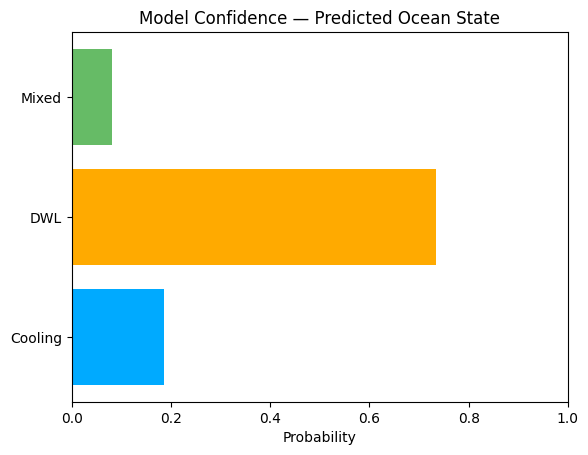

In [ ]:
import matplotlib.pyplot as plt

probs = predicted_prob[0]
classes = list(model.classes_)

plt.barh(classes, probs, color=['#00aaff', '#ffaa00', '#66bb66'])
plt.xlabel("Probability")
plt.title("Model Confidence — Predicted Ocean State")
plt.xlim(0, 1)
plt.show()


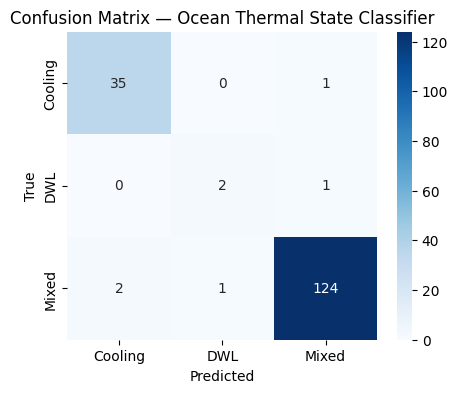

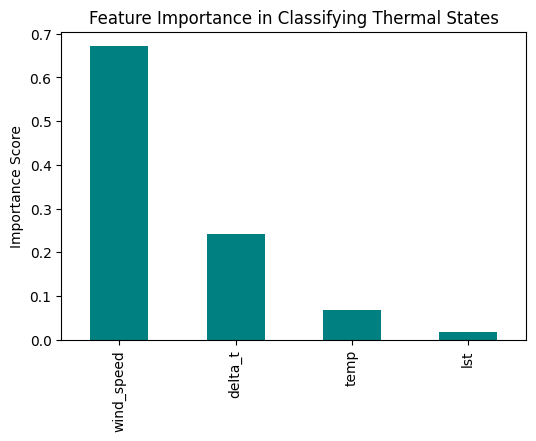

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Ocean Thermal State Classifier")
plt.show()


# Feature importance
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(6,4))
feat_imp.plot(kind='bar', color='teal')
plt.title("Feature Importance in Classifying Thermal States")
plt.ylabel("Importance Score")
plt.show()


Ocean Health Indicator — Thermal Stability Index (TSI)

In [ ]:
# --- PHASE 3: THERMAL STABILITY INDEX (TSI) ---
surface_argo['tsi'] = surface_argo['delta_t'] / surface_argo['wind_speed']
surface_argo['tsi'] = surface_argo['tsi'].replace([np.inf, -np.inf], np.nan)

print("\nThermal Stability Index (ΔT / wind_speed) summary:")
print(surface_argo['tsi'].describe())




Thermal Stability Index (ΔT / wind_speed) summary:
count    682.000000
mean       0.027185
std        0.173470
min       -0.644809
25%       -0.068115
50%        0.028363
75%        0.125437
max        0.743021
Name: tsi, dtype: float64


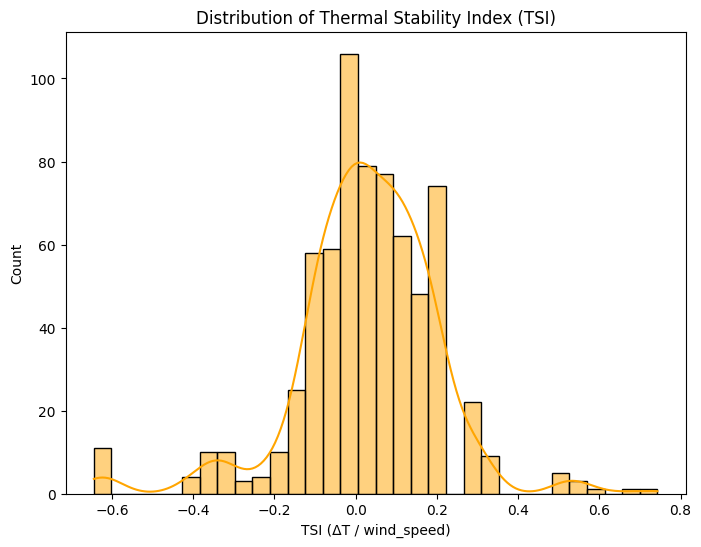

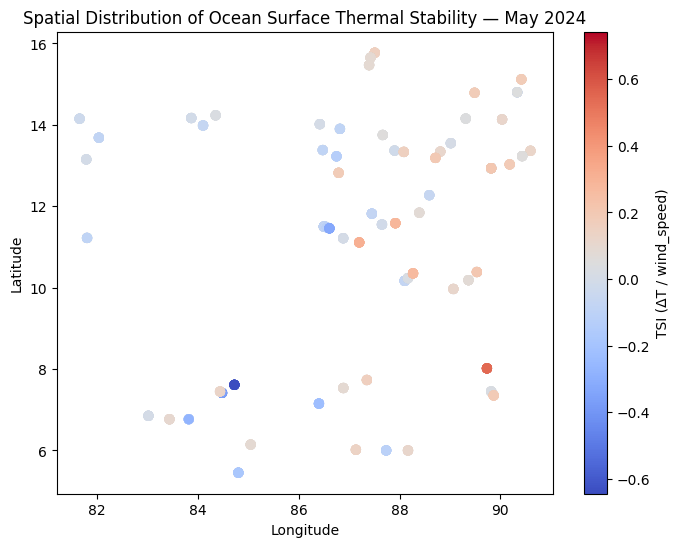

In [ ]:
# Plot histogram
plt.figure(figsize=(8,6))
sns.histplot(surface_argo['tsi'], kde=True, color='orange')
plt.title("Distribution of Thermal Stability Index (TSI)")
plt.xlabel("TSI (ΔT / wind_speed)")
plt.show()

# Spatial pattern
plt.figure(figsize=(8,6))
plt.scatter(surface_argo['lon'], surface_argo['lat'], c=surface_argo['tsi'], cmap='coolwarm', s=40)
plt.colorbar(label='TSI (ΔT / wind_speed)')
plt.title("Spatial Distribution of Ocean Surface Thermal Stability — May 2024")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


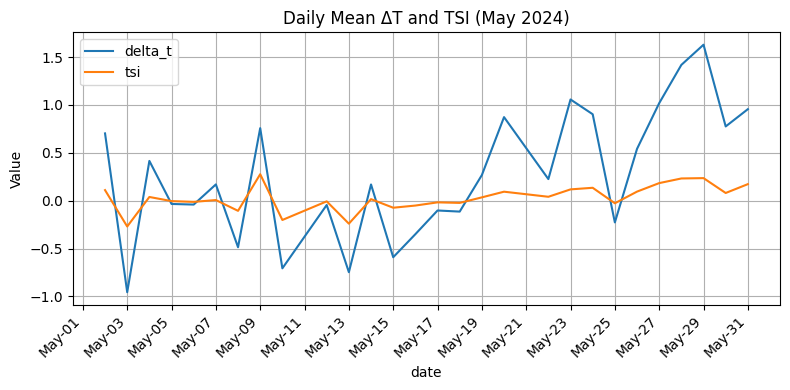

In [ ]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(8,4))
daily_mean.plot(ax=ax, title="Daily Mean ΔT and TSI (May 2024)")
ax.set_ylabel("Value")
ax.grid(True)

# Format x-axis for dates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))  # show every 2 days
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Prediction

In [ ]:
import pandas as pd

# Example input as a DataFrame (same columns as model expects)
sample_input = pd.DataFrame({
    'wind_speed': [2.8],
    'delta_t': [0.9],
    'lst': [12.0],
    'temp': [31.5]
})

# Predict class
predicted_class = model.predict(sample_input)
predicted_prob = model.predict_proba(sample_input)

print("Predicted Ocean State:", predicted_class[0])
print("Prediction Probabilities:", dict(zip(model.classes_, predicted_prob[0])))


Predicted Ocean State: DWL
Prediction Probabilities: {'Cooling': np.float64(0.185), 'DWL': np.float64(0.735), 'Mixed': np.float64(0.08)}


In [ ]:
test_samples = pd.DataFrame([
    {'wind_speed': 2.5, 'delta_t': 0.8, 'lst': 13, 'temp': 31.7},
    {'wind_speed': 6.0, 'delta_t': 0.2, 'lst': 14, 'temp': 31.0},
    {'wind_speed': 4.5, 'delta_t': -0.5, 'lst': 20, 'temp': 30.9}
])
preds = model.predict(test_samples)
print(preds)

['DWL' 'Mixed' 'Cooling']
